In [30]:
import warnings
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,r2_score,mean_absolute_error,mean_squared_error


from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import datetime
# importing reports for metrics values
from sklearn.metrics import classification_report   




In [2]:
warnings.filterwarnings("ignore")

In [3]:
dt = pd.read_csv("car data.csv")
dt.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
import seaborn as sns

In [5]:
date_year=datetime.datetime.now()
dt['age'] = date_year.year - dt['Year']
dt.drop(['Year','Car_Name'],axis=1,inplace=True)



<Axes: xlabel='Selling_Price'>

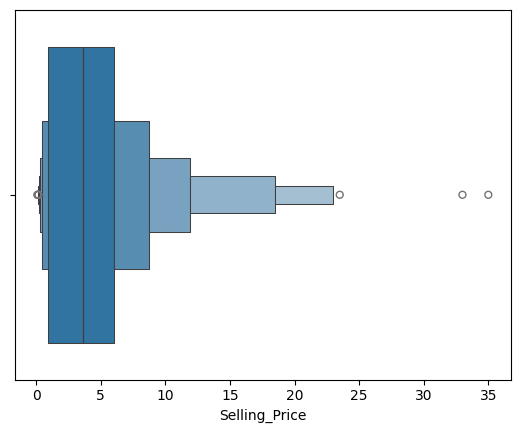

In [6]:
sns.boxenplot(x=dt['Selling_Price'])


In [9]:
#fixing outliers in Selling Price
dt=dt[~(dt['Selling_Price']>=33.0) & (dt['Selling_Price']<=35.0)]


<Axes: xlabel='Selling_Price'>

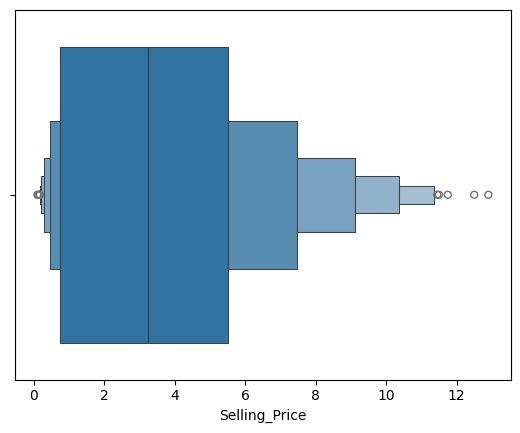

In [7]:
#fixing outliers in Selling Price
q1=dt['Selling_Price'].quantile(0.25)
q3=dt['Selling_Price'].quantile(0.75)
iqr=q3-q1
upper_bound=q3+1.5*iqr
dt=dt[dt['Selling_Price']<upper_bound]
sns.boxenplot(x=dt['Selling_Price'])


In [12]:
#encoding categorical columns
dt['Fuel_Type'].replace({'Petrol':0,'Diesel':1,'CNG':2},inplace=True)
dt['Seller_Type'].replace({'Dealer':0,'Individual':1},inplace=True)
dt['Transmission'].replace({'Manual':0,'Automatic':1},inplace=True)


In [13]:
#store features and target variable
X=dt.drop('Selling_Price',axis=1)
y=dt['Selling_Price']


In [14]:
#splitting the data into training and testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [34]:
# models training
rf=RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
r2_score(y_test,y_pred_rf)
print("Random Forest Regressor R2 Score:",r2_score(y_test,y_pred_rf))



lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
r2_score(y_test,y_pred_lr)
print("Linear Regression R2 Score:",r2_score(y_test,y_pred_lr))

gb=GradientBoostingRegressor()
gb.fit(X_train,y_train)
y_pred_gb=gb.predict(X_test)
r2_score(y_test,y_pred_gb)
print("Gradient Boosting Regressor R2 Score:",r2_score(y_test,y_pred_gb))

xgb=XGBRegressor()
xgb.fit(X_train,y_train)
y_pred_xgb=xgb.predict(X_test)
r2_score(y_test,y_pred_xgb) 
print("XGBoost Regressor R2 Score:",r2_score(y_test,y_pred_xgb))


Random Forest Regressor R2 Score: 0.9279628078003049
Linear Regression R2 Score: 0.7564021588704564
Gradient Boosting Regressor R2 Score: 0.9528382991470202
XGBoost Regressor R2 Score: 0.9386483764695104


In [39]:
# models evaluation - use regression metrics (classification_report expects discrete labels)
def regression_report(y_true, y_pred, name):
	print(f"{name} Regression Report:")
	print(f" R2 Score: {r2_score(y_true, y_pred):.4f}")
	print(f" MAE:      {mean_absolute_error(y_true, y_pred):.4f}")
	print(f" MSE:      {mean_squared_error(y_true, y_pred):.4f}")
	print(f" RMSE:     {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}\n")

regression_report(y_test, y_pred_rf, "Random Forest")
regression_report(y_test, y_pred_lr, "Linear Regression")
regression_report(y_test, y_pred_gb, "Gradient Boosting")
regression_report(y_test, y_pred_xgb, "XGBoost")


Random Forest Regression Report:
 R2 Score: 0.9280
 MAE:      0.4999
 MSE:      0.6765
 RMSE:     0.8225

Linear Regression Regression Report:
 R2 Score: 0.7564
 MAE:      1.0822
 MSE:      2.2878
 RMSE:     1.5125

Gradient Boosting Regression Report:
 R2 Score: 0.9528
 MAE:      0.4839
 MSE:      0.4429
 RMSE:     0.6655

XGBoost Regression Report:
 R2 Score: 0.9386
 MAE:      0.5011
 MSE:      0.5762
 RMSE:     0.7591



In [46]:
# ceating a dataframe to compare the actual and predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted_RF': y_pred_rf, 'Predicted_LR': y_pred_lr, 'Predicted_GB': y_pred_gb, 'Predicted_XGB': y_pred_xgb})
comparison_df.head()    
    

,Actual,Predicted_RF,Predicted_LR,Predicted_GB,Predicted_XGB
9,7.45,7.3605,6.457694,7.162268,7.800578
270,4.10,3.4100,4.678006,4.062191,3.260773
174,0.38,0.3453,0.878300,0.359649,0.282997
226,5.25,4.7130,4.372041,4.588154,4.818189
89,4.75,4.1390,4.419335,3.925131,4.141297


<BarContainer object of 4 artists>

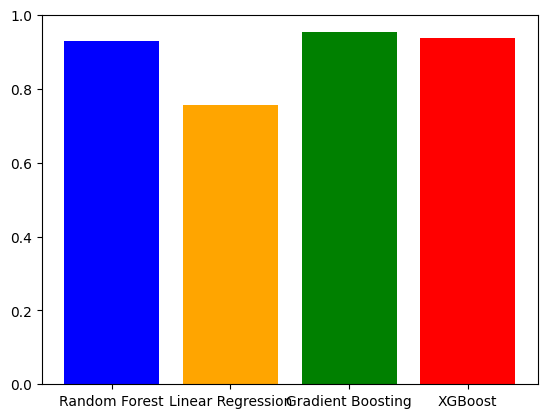

In [47]:
# create a graph to compare models r2 scores
models = ['Random Forest', 'Linear Regression', 'Gradient Boosting', 'XGBoost']
r2_scores = [r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_gb), r2_score(y_test, y_pred_xgb)]
plt.bar(models, r2_scores, color=['blue', 'orange', 'green', 'red'])


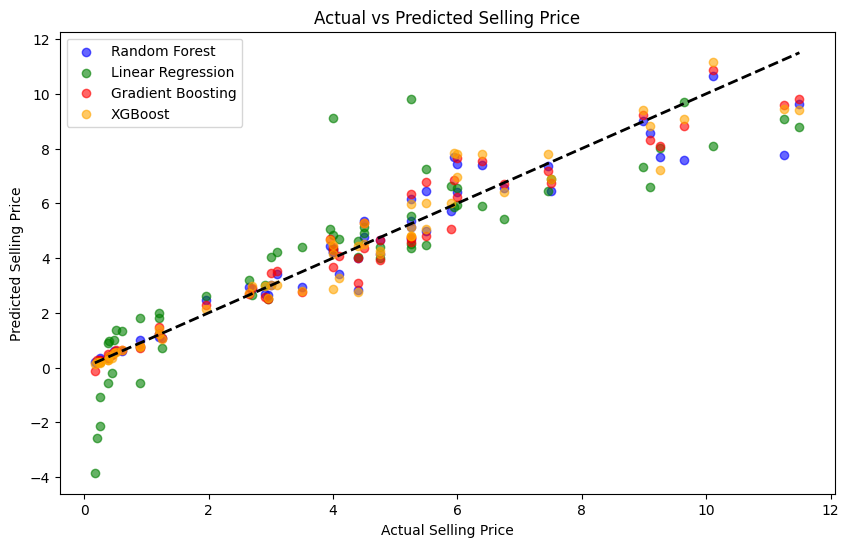

In [43]:
# graphical representation of actual vs predicted values 
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf, color='blue', label='Random Forest', alpha=0.6)
plt.scatter(y_test, y_pred_lr, color='green', label='Linear Regression', alpha=0.6)
plt.scatter(y_test, y_pred_gb, color='red', label='Gradient Boosting', alpha=0.6)
plt.scatter(y_test, y_pred_xgb, color='orange', label='XGBoost', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.legend()
plt.show()


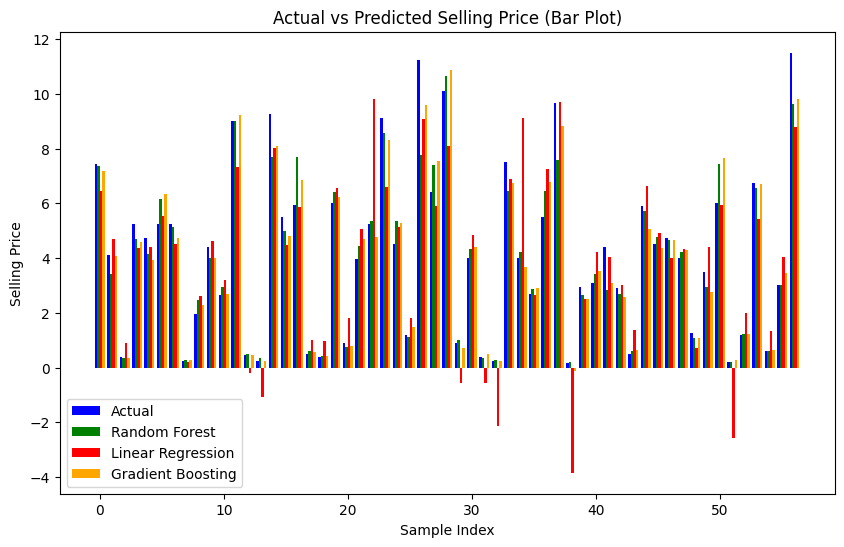

In [45]:
# use barplot representation of actual vs predicted values 
plt.figure(figsize=(10,6))
x = np.arange(len(y_test))
width = 0.2
plt.bar(x - 1.5*width, y_test, width, label='Actual', color='blue')
plt.bar(x - 0.5*width, y_pred_rf, width, label='Random Forest', color='green')
plt.bar(x + 0.5*width, y_pred_lr, width, label='Linear Regression', color='red')
plt.bar(x + 1.5*width, y_pred_gb, width, label='Gradient Boosting', color='orange')
plt.xlabel('Sample Index')
plt.ylabel('Selling Price')
plt.title('Actual vs Predicted Selling Price (Bar Plot)')
plt.legend()
plt.show()

In [40]:
# save the report as csv file
import csv
with open('regression_report.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Model', 'R2 Score', 'MAE', 'MSE', 'RMSE'])
    
    models = {
        "Random Forest": y_pred_rf,
        "Linear Regression": y_pred_lr,
        "Gradient Boosting": y_pred_gb,
        "XGBoost": y_pred_xgb
    }
    
    for name, y_pred in models.items():
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        writer.writerow([name, f"{r2:.4f}", f"{mae:.4f}", f"{mse:.4f}", f"{rmse:.4f}"])

        
        

In [41]:
# saving the best model
import pickle
with open('car_price_prediction_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
    
    
    
    


In [48]:
# predicting a new data point
# Make sure the input has the same 7 features in the same order as X.columns:
# ['Present_Price','Kms_Driven','Fuel_Type','Seller_Type','Transmission','Owner','age']
new_sample = pd.DataFrame([{
	'Present_Price': 7.85,
	'Kms_Driven': 30000,   # example value
	'Fuel_Type': 0,        # Petrol=0, Diesel=1, CNG=2
	'Seller_Type': 1,      # Individual=1, Dealer=0
	'Transmission': 0,     # Manual=0, Automatic=1
	'Owner': 0,
	'age': 5
}], columns=X.columns)  # ensure correct column order

# sanity check before prediction
if new_sample.shape[1] != rf.n_features_in_:
	raise ValueError(f"Expected {rf.n_features_in_} features, got {new_sample.shape[1]}")

predicted_price = rf.predict(new_sample)
print(f"Predicted Selling Price: {predicted_price[0]:.2f} lakhs")


Predicted Selling Price: 5.73 lakhs
